# BlueDot Technical AI Safety Puzzle #1 — Worked Solution

> https://bluedot.org/puzzles/technical-ai-safety

**The puzzle.** A small classifier reads a short sentence and predicts 8 independent yes/no
features at once (`number, question, color, food, sentiment, country, person, body_part`),
each at >95% accuracy. The architecture is:

`MiniLM sentence encoder (384-d)` → `5-layer MLP with ReLUs` → `8 sigmoids`.

After a particular layer **L** (post-ReLU of hidden layer 2, a 64-d activation),
**7 of the 8 features are stored linearly** — each is "a single direction" you can read with a
linear probe. **One feature is not.** Our job:

- **Task 1** — find the non-linear feature.
- **Task 2** — explain the geometry it uses instead.
- **Task 3** — NOT INCLUDED

**How we tell linear from non-linear:** for each feature we fit a *linear probe* (logistic
regression) and a *non-linear probe* (small MLP) on the layer-L activations and compare test
AUC. If a single direction encodes the feature, the two probes tie. If the linear probe lags
badly, the feature is stored non-linearly.

## Setup
Loads the encoder (first run downloads it, ~30s), the trained head, and the data.

One model, one shared body, predicting all 8 labels at once from a single sentence — not 8 separate models.

Q) Do the probabilities generated by the independent sigmoids for each feature sum to 1?

A) Each of the 8 outputs gets its own independent sigmoid, so each is a separate yes/no probability between 0 and 1. They're not in competition, so there's no reason for them to add up to anything in particular.

In [1]:
!pip install -q sentence-transformers torch scikit-learn
import json, numpy as np, torch, torch.nn as nn
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings; warnings.filterwarnings("ignore")        # quiet sklearn/numpy chatter
np.seterr(all="ignore")
torch.manual_seed(0); np.random.seed(0)

# If running on Colab, clone the repo first:
# !([ -d bluedot-tais-puzzle ] || git clone https://github.com/SamDower/bluedot-tais-puzzle.git)
# %cd bluedot-tais-puzzle

class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384,64), nn.ReLU(),   # hidden 0
            nn.Linear(64,64),  nn.ReLU(),   # hidden 1
            nn.Linear(64,64),  nn.ReLU(),   # hidden 2  <- analyze post-ReLU here (layer L)
            nn.Linear(64,64),  nn.ReLU(),   # hidden 3
            nn.Linear(64,8),                # logits
        )
    def forward(self, x): return self.layers(x)

enc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
m = Head(); m.load_state_dict(torch.load("model.pt", map_location="cpu", weights_only=False)); m.eval()
feature_names = json.load(open("feature_names.json"))

def load_jsonl(p):
    t, l = [], []
    for line in open(p):
        d = json.loads(line); t.append(d["text"]); l.append(d["labels"])
    return t, np.array(l)
tr_t, tr_y = load_jsonl("train.jsonl")
te_t, te_y = load_jsonl("test.jsonl")
print(len(tr_t), "train /", len(te_t), "test examples; features:", feature_names)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

7000 train / 1500 test examples; features: ['number', 'question', 'color', 'food', 'sentiment', 'country', 'person', 'body_part']


In [2]:
print('\nFirst 5 training texts (tr_t):\n', tr_t[:5])
print('First 5 rows of training labels (tr_y):\n', tr_y[:5])

print('\nFirst 5 test texts (te_t):\n', te_t[:5])
print('\nFirst 5 rows of test labels (te_y):\n', te_y[:5])


First 5 training texts (tr_t):
 ['The driver eats those sad oatmeal dressed in brown in Netherlands.', 'Kevin visits Ecuador, calling it harsh and bought a few songs wearing a red jacket throughout the unexpected week.', 'This morning, Carlos ate the fantastic pictures with a red cover during the long quiet afternoon.', 'On this morning, did Tony sell the delighted magazines in Kazakhstan?', 'On right now, does the artist find the lame boxes in Morocco?']
First 5 rows of training labels (tr_y):
 [[0 0 1 1 0 1 0 0]
 [0 0 1 0 0 1 1 0]
 [0 0 1 0 1 0 1 0]
 [0 1 0 0 1 1 1 0]
 [0 1 0 0 0 1 0 0]]

First 5 test texts (te_t):
 ['The worker is happy, and runs near a plate of mushroom under a turquoise sky in Haiti covering the ear while the children played outside.', 'Did the scientist eat those marvelous games with a sense of curiosity?', 'The traveler visits the museum, calling it incredible and bought a few magazines by the brown door.', 'Did Ian eat those dreadful maps on a magenta carpet i

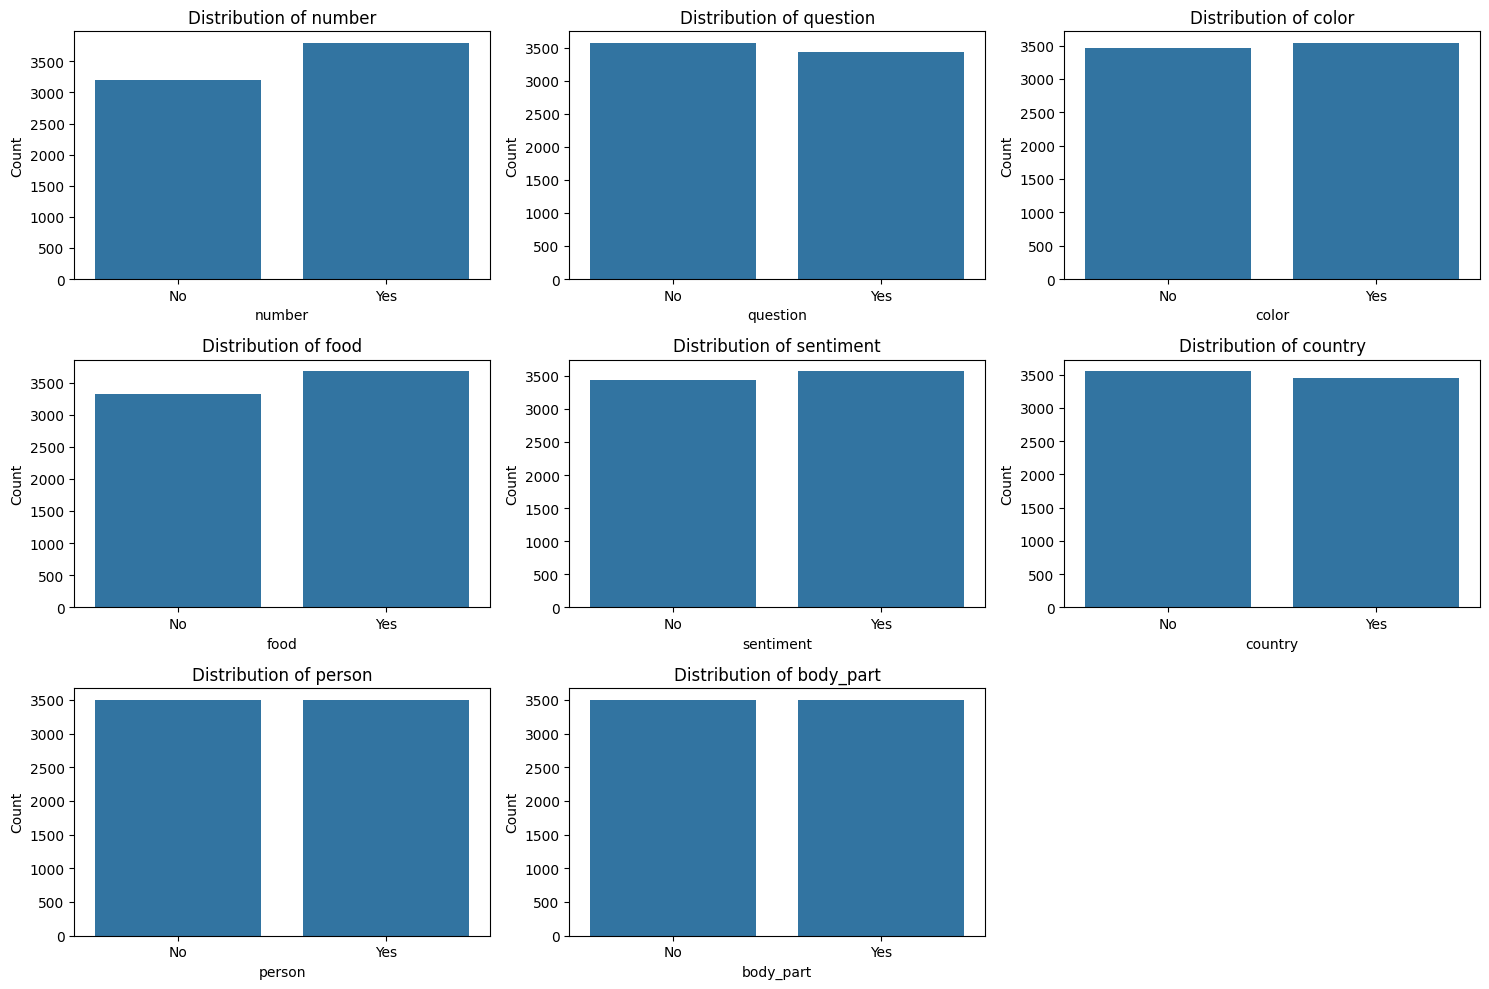

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, name in enumerate(feature_names):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.countplot(x=tr_y[:, i])
    plt.title(f'Distribution of {name}')
    plt.xlabel(name)
    plt.ylabel('Count')
    plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

We embed every sentence once (cached), then push through `m.layers[:6]` to get the
layer-L activation — the output of the 3rd ReLU, a 64-dim vector.

In [4]:
_emb_cache = {}
def embed(texts, key):
    if key not in _emb_cache:
        _emb_cache[key] = enc.encode(texts, convert_to_numpy=True, batch_size=256, show_progress_bar=False)
    return _emb_cache[key]

def layerL_acts(texts, key):
    E = torch.from_numpy(embed(texts, key))
    with torch.no_grad():
        return m.layers[:6](E).numpy()   # (N, 64) post-ReLU of hidden 2

Xtr = layerL_acts(tr_t, "train")
Xte = layerL_acts(te_t, "test")
print("layer-L activations:", Xtr.shape, Xte.shape)

layer-L activations: (7000, 64) (1500, 64)


In [5]:
print('Shape of Xtr:', Xtr.shape)
print('Shape of ytr:', tr_y.shape)
print('Shape of Xte:', Xte.shape)
print('Shape of yte:', te_y.shape)

Shape of Xtr: (7000, 64)
Shape of ytr: (7000, 8)
Shape of Xte: (1500, 64)
Shape of yte: (1500, 8)


## Task 1 — Find the non-linear feature
Linear probe vs. non-linear (MLP) probe, per feature.

For this analysis, using either AUC or accuracy would yield similar results because the dataset is largely balanced. However, AUC is generally a safer metric as it is robust to imbalanced datasets, which accuracy can be sensitive to.

In [6]:
print(f"{'feature':12} {'lin_auc':>8} {'mlp_auc':>8} {'gap':>8}")
print("-"*40)
results = []
for j, name in enumerate(feature_names):
    ytr, yte = tr_y[:, j], te_y[:, j]
    lin = LogisticRegression(max_iter=3000).fit(Xtr, ytr)
    lauc = roc_auc_score(yte, lin.predict_proba(Xte)[:, 1])
    mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=600, random_state=0).fit(Xtr, ytr)
    mauc = roc_auc_score(yte, mlp.predict_proba(Xte)[:, 1])
    results.append((name, lauc, mauc, mauc-lauc))
    print(f"{name:12} {lauc:8.3f} {mauc:8.3f} {mauc-lauc:8.3f}")
winner = max(results, key=lambda r: r[3])[0]
print(f"\n>> Non-linear feature = '{winner}'  (linear probe collapses; MLP is fine)")

feature       lin_auc  mlp_auc      gap
----------------------------------------
number          0.998    0.997   -0.000
question        1.000    1.000    0.000
color           0.997    0.997   -0.000
food            0.996    0.996   -0.000
sentiment       0.995    0.995    0.000
country         0.472    0.993    0.522
person          1.000    1.000    0.000
body_part       0.999    0.999    0.000

>> Non-linear feature = 'country'  (linear probe collapses; MLP is fine)


**Result:** every feature except **`country`** has linear AUC ≈ non-linear AUC ≈ 1.0.
For `country`, the linear probe scores ~**0.47 — below chance** — while the MLP scores ~0.99.
A single direction not only fails to encode country, it's slightly *anti*-correlated. That
below-0.5 score is the tell-tale sign of a complex, symmetric pattern where positives appear on
*both* sides of every straight line. **Country is the non-linear feature.**

## Task 2 — How is `country` represented?

We test three hypotheses for why a simple linear method struggles with the 'country' feature:
1. **Curved boundary** — Can we make it linear by adding squared features? If this helps a lot, it means the decision boundary is curved, not straight.
2. **Interaction with another feature** — Does 'country' become easy to classify if we only look at data where another feature (like 'food') has a specific value? If so, 'country' interacts strongly with that other feature.
3. **Reversing direction** — Does the "direction" in the data that points to 'country' reverse when another feature changes its value? If the angle between these directions is close to 180 degrees (cosine near -1), it means the feature literally flips its meaning.


This hypothesis (number 2 above) investigates if the 'country' feature becomes easy to separate (linearly) when we look at only specific parts of the data. These parts are defined by the values of another feature. For example, 'country' might be easy to classify when 'food' is 'yes', and also easy when 'food' is 'no', but difficult when 'food' is ignored entirely.

*  Input: We use the layer-L activations (Xtr, Xte) and all the binary labels (tr_y, te_y). We are specifically interested in the 'country' label (ctr, cte) and how it behaves when we consider the values of another feature `k` (like 'food', 'color', etc.), using `tr_y[:,k]` and `te_y[:,k]`.

*  Process: For every other feature, we divide the dataset into two groups: one where that feature is 0, and another where it's 1. Within each group, we train a separate simple linear model (logistic regression) to predict the 'country' label (0 or 1).

*  Output: The AUC scores for 'country' within each of these divided groups. If these scores are high (for example, 0.975 and 0.967 for 'food'), it suggests that 'country' becomes linearly separable when we consider it alongside that specific feature.

In [ ]:
y = f(x)
f(x) = w4(w3s(.....))

y = a1x1 + a2x2 + a3x1x3

In [8]:
from sklearn.preprocessing import StandardScaler
CI = feature_names.index("country")
ctr, cte = tr_y[:, CI], te_y[:, CI]

# (1) quadratic boundary
def quad(X): return np.concatenate([X, X**2], 1)
sc = StandardScaler().fit(quad(Xtr))
q = LogisticRegression(max_iter=5000).fit(sc.transform(quad(Xtr)), ctr)
print(f"linear direction        AUC = {roc_auc_score(cte, LogisticRegression(max_iter=3000).fit(Xtr,ctr).predict_proba(Xte)[:,1]):.3f}")
print(f"linear + squared feats  AUC = {roc_auc_score(cte, q.predict_proba(sc.transform(quad(Xte)))[:,1]):.3f}")

# (2) condition on each other feature
print("\ncountry AUC when we fit a linear probe WITHIN each subset:")
for k, kn in enumerate(feature_names):
    if k == CI: continue
    a = []
    for v in (0, 1):
        mtr, mte = tr_y[:,k]==v, te_y[:,k]==v
        if len(np.unique(cte[mte])) < 2: a.append(float('nan')); continue
        lp = LogisticRegression(max_iter=2000).fit(Xtr[mtr], ctr[mtr])
        a.append(roc_auc_score(cte[mte], lp.predict_proba(Xte[mte])[:,1]))
    flag = "  <== entangled!" if min(a) > 0.9 else ""
    print(f"   split by {kn:10}: {kn}=0 -> {a[0]:.3f} | {kn}=1 -> {a[1]:.3f}{flag}")

linear direction        AUC = 0.472
linear + squared feats  AUC = 0.941

country AUC when we fit a linear probe WITHIN each subset:
   split by number    : number=0 -> 0.639 | number=1 -> 0.576
   split by question  : question=0 -> 0.595 | question=1 -> 0.598
   split by color     : color=0 -> 0.567 | color=1 -> 0.529
   split by food      : food=0 -> 0.975 | food=1 -> 0.967  <== entangled!
   split by sentiment : sentiment=0 -> 0.868 | sentiment=1 -> 0.928
   split by person    : person=0 -> 0.494 | person=1 -> 0.602
   split by body_part : body_part=0 -> 0.567 | body_part=1 -> 0.562


In [9]:
FI = feature_names.index("food")
def cdir(mask):
    w = LogisticRegression(max_iter=3000).fit(Xtr[mask], ctr[mask]).coef_[0]
    return w/np.linalg.norm(w)
w0, w1 = cdir(tr_y[:,FI]==0), cdir(tr_y[:,FI]==1)
print(f"cos( country-dir | food=0 ,  country-dir | food=1 ) = {w0@w1:+.3f}")
print("(-1 == direction reverses when food flips)")

cos( country-dir | food=0 ,  country-dir | food=1 ) = -0.991
(-1 == direction reverses when food flips)


**Result.**
- Single direction: **AUC ≈ 0.47** (fails). Adding squared features: **≈ 0.94** (works) → this means the decision boundary is *curved*, not a simple straight line.
- When we consider **`food`**, 'country' becomes much easier to classify (linearly separable) in *both* subsets (with AUCs **≈ 0.97**) → this shows 'country' **interacts strongly with food**.
- The "direction" in the data that represents 'country' when food=0 versus when food=1 has a cosine **≈ −0.99** → this means the direction literally **reverses** depending on whether the 'food' feature is present or absent.

**Interpretation.** The 'country' feature isn't simply represented along its own single axis in the data. Instead, its meaning is tied to the 'food' feature in a way that creates a complex interaction. When 'food' is present, the model interprets 'country' in one way, but when 'food' is absent, it interprets 'country' in the opposite way.

Because of this reversal, a simple linear model (looking for one consistent direction) struggles significantly, as 'country' positive examples might appear on both sides of any single straight line. However, the model's more complex, non-linear parts can still identify 'country' by understanding this **interaction** between the 'country' information and the 'food' information. This is a good example of how two different concepts can be represented in a shared space and then separated by more advanced processing.

**Conclusion.** *Why we check whether a feature is linear at a specific layer*

-  A neural network doesn't store a concept in one fixed place — it re-shapes its internal representation at every layer (each layer applies ReLU(W·x + b), a rotate–stretch–bend). So whether a feature is "a simple direction" isn't a property of the model; it's a property of the model at a chosen layer. That's why we always pin down which layer we're probing.

-  The geometry changes with depth. A concept can be tangled at one layer and cleanly linear at the next — the network gradually "untangles" features as information flows forward.

-  The output layer is linear by construction, so probing it tells us little — the model is built to make its final answer linearly readable. The interesting computation is in the middle layers.

-  A middle layer shows the work in progress. Finding country non-linear at layer L means the network is still doing non-linear work on it there — while the other 7 features are already resolved. That's a clue about the model's internal algorithm.

-  It matters in practice. Monitoring, probing, and steering all happen at internal layers — so your conclusion ("does the model represent X?") and your ability to intervene depend entirely on which layer you read and what kind of probe you use.

-  The safety lesson: if you'd only probed layer L with a linear probe, you'd wrongly conclude "the model doesn't encode country." It does — just non-linearly, right there. Absence of a linear signal is not absence of the concept.

-  Takeaway: "Is feature X linear?" is incomplete. The real question is "Is feature X linear at layer L?" — sweep the layers, and where a feature becomes linear tells you how and where the network computes it.